<a href="https://colab.research.google.com/github/trngchnn/opinion-manipulation-abm-pilot-study/blob/main/Markov_Chain_Sentiment_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CHẤM ĐIỂM SENTIMENT LIÊN TỤC VÀ TRÍCH XUẤT CHUỖI MARKOV

> **Lưu ý:** Trong thời gian chờ phê duyệt chính thức `PRAW API` từ Reddit, nhóm nghiên cứu chủ động sử dụng tập dữ liệu tương tác thực tế từ Kaggle để làm dữ liệu thực nghiệm (Proxy data).

* **Mục tiêu file code này:**
  1. Chấm điểm cảm xúc liên tục và phân loại các chuỗi thảo luận thành 3 trạng thái rời rạc: Tiêu cực (`-1`), Trung lập (`0`), và Tích cực (`1`).
  2. Phân tích sự dịch chuyển quan điểm giữa người phản hồi (`Child`) và người bị phản hồi (`Parent`).
  3. Lập **Ma trận xác suất chuyển trạng thái Markov 3x3** để lượng hóa chính xác xác suất một cá nhân bị "bẻ lái" tư tưởng sau khi tiếp xúc với các ý kiến định hướng. Kết quả ma trận này sẽ là bộ quy tắc ứng xử cốt lõi để nạp vào mô hình mô phỏng ABM (ở file kế tiếp).

---
### DATA SCHEMA THỰC TẾ (INTERACTION DATA)

Nhóm tiến hành chuẩn hóa dữ liệu tương tác theo các trường thuộc tính sau để phục vụ tính toán Chuỗi Markov:

| Trường dữ liệu (Features) | Vai trò kỹ thuật trong mô hình toán Markov |
| :--- | :--- |
| `sentiment_child` / `sentiment_parent` | Điểm số cảm xúc liên tục trong dải từ $[-1, 1]$ của người phản hồi và người bị phản hồi. |
| `state_child` / `state_parent` | Trạng thái ý kiến rời rạc (`-1`, `0`, `1`). Đây là đầu vào trực tiếp để lập ma trận chuyển trạng thái Markov. |
| `author` / `parent_author` | Xác định cặp tác nhân tương tác trực tiếp để theo dõi luồng lây lan quan điểm vi mô. |

In [ ]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import entropy
from google.colab import drive

drive.mount('/content/drive')

path_pos = "/content/drive/MyDrive/dataset1/comments_positive.csv"
path_neg = "/content/drive/MyDrive/dataset1/comments_negative.csv"

sample_size_per_file = 20000
chunk_size = 10000  # Mỗi lượt chỉ nạp 10.000 dòng vào bộ nhớ tạm

# Chỉ lấy đúng các cột phục vụ cho thuật toán để tối ưu dung lượng
columns_to_keep = ['parent_id', 'text', 'score', 'author', 'parent_text', 'parent_score', 'parent_author']

pos_list = []
neg_list = []

for chunk in pd.read_csv(path_pos, chunksize=chunk_size, usecols=columns_to_keep, low_memory=False):
    # Loại bỏ các dòng trống hoặc tài khoản vô danh ẩn của hệ thống
    chunk_clean = chunk.dropna(subset=['text', 'parent_text', 'author', 'parent_author'])
    chunk_clean = chunk_clean[(chunk_clean['author'] != '[deleted]') & (chunk_clean['parent_author'] != '[deleted]')]

    pos_list.append(chunk_clean)
    if sum(len(c) for c in pos_list) >= sample_size_per_file:
        break
df_pos_sample = pd.concat(pos_list, ignore_index=True).head(sample_size_per_file)
df_pos_sample["binary_label"] = 1

for chunk in pd.read_csv(path_neg, chunksize=chunk_size, usecols=columns_to_keep, low_memory=False):
    chunk_clean = chunk.dropna(subset=['text', 'parent_text', 'author', 'parent_author'])
    chunk_clean = chunk_clean[(chunk_clean['author'] != '[deleted]') & (chunk_clean['parent_author'] != '[deleted]')]

    neg_list.append(chunk_clean)
    if sum(len(c) for c in neg_list) >= sample_size_per_file:
        break
df_neg_sample = pd.concat(neg_list, ignore_index=True).head(sample_size_per_file)
df_neg_sample["binary_label"] = 0

df_clean = pd.concat([df_pos_sample, df_neg_sample], ignore_index=True)
df_clean = df_clean.drop_duplicates(subset=['text', 'parent_text'])
print(f"-> Chunking hoàn tất! Đã bóp nhỏ dữ liệu thành tập mẫu an toàn: {df_clean.shape[0]} dòng.")


author_counts = df_clean['author'].value_counts()
Q1 = author_counts.quantile(0.25)
Q3 = author_counts.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Định danh các tài khoản có tần suất hoạt động vượt ngưỡng dị biệt
spammers = author_counts[author_counts > upper_bound].index.tolist()
print(f"-> Thuật toán IQR phát hiện: {len(spammers)} tài khoản hoạt động bất thường.")

# Tiến hành loại bỏ các tài khoản này ra khỏi mô hình tương tác
df_clean = df_clean[~df_clean['author'].isin(spammers)].copy()
print(f"-> Đã lọc sạch nhiễu. Kích thước dữ liệu thực nghiệm: {len(df_clean)} dòng.")


# Sử dụng NetworkX để dựng đồ thị có hướng (Từ người phản hồi trước đến người phản hồi sau)
G = nx.from_pandas_edgelist(
    df_clean,
    source='parent_author',
    target='author',
    create_using=nx.DiGraph()
)

print(f"-> Cấu trúc mạng lưới (Reply-tree) được thiết lập thành công:")
print(f"   + Số lượng Tác nhân (Nodes/Users): {G.number_of_nodes()}")
print(f"   + Số lượng Liên kết hội thoại (Edges/Replies): {G.number_of_edges()}")

# Tính toán Degree Centrality để xác định vị trí chiến lược bị đánh phá
centrality = nx.degree_centrality(G)
top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"-> TOP 3 Tài khoản có tầm ảnh hưởng cấu trúc lớn nhất: {top_nodes}")


# Tải bộ dữ liệu từ điển cảm xúc học thuật
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Tự động ánh xạ nội dung text của cha và con thành điểm số liên tục [-1, 1]
df_clean['sentiment_child'] = df_clean['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_clean['sentiment_parent'] = df_clean['parent_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Hàm chuyển đổi điểm liên tục sang 3 Trạng thái (State) phục vụ bài toán ma trận Markov
def map_to_state(score):
    if score <= -0.05: return -1   # Trạng thái Tiêu cực / Phản đối
    elif score >= 0.05: return 1   # Trạng thái Tích cực / Đồng thuận
    else: return 0                 # Trạng thái Trung lập

df_clean['state_child'] = df_clean['sentiment_child'].apply(map_to_state)
df_clean['state_parent'] = df_clean['sentiment_parent'].apply(map_to_state)
print("-> Đã thiết lập xong các mảng trạng thái tâm lý người dùng.")



# Thống kê toán học 1: Shannon Entropy tổng thể
prob_dist = df_clean['state_child'].value_counts(normalize=True)
overall_entropy = entropy(prob_dist, base=2)

print("\n" + "="*60)
print(f" KẾT QUẢ ĐỊNH LƯỢNG 1: SHANNON ENTROPY = {overall_entropy:.4f} bits")
print("  (Giá trị Entropy tiệm cận về 0 chỉ ra sự biến mất của tính đa dạng ý kiến)")

# Thống kê toán học 2: Ma trận chuyển trạng thái Markov
markov_matrix = pd.crosstab(df_clean['state_parent'], df_clean['state_child'], normalize='index')

print("\n KẾT QUẢ ĐỊNH LƯỢNG 2: MA TRẬN XÁC SUẤT CHUYỂN TRẠNG THÁI MARKOV")
print("  (Hàng đại diện cho Trạng thái Cha -> Cột đại diện cho Trạng thái Con)")
print("-"*60)
print(markov_matrix)
print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Chunking hoàn tất! Đã bóp nhỏ dữ liệu thành tập mẫu an toàn: 39953 dòng.
-> Thuật toán IQR phát hiện: 4700 tài khoản hoạt động bất thường.
-> Đã lọc sạch nhiễu. Kích thước dữ liệu thực nghiệm: 23309 dòng.
-> Cấu trúc mạng lưới (Reply-tree) được thiết lập thành công:
   + Số lượng Tác nhân (Nodes/Users): 39654
   + Số lượng Liên kết hội thoại (Edges/Replies): 23309
-> TOP 3 Tài khoản có tầm ảnh hưởng cấu trúc lớn nhất: [('Shut_Up_Dude', 0.0016896577812523642), ('PSY_Oppa', 0.0005295942299447709), ('Drunken_Economist', 0.00047915668423574505)]
-> Đã thiết lập xong các mảng trạng thái tâm lý người dùng.

 KẾT QUẢ ĐỊNH LƯỢNG 1: SHANNON ENTROPY = 1.5782 bits
  (Giá trị Entropy tiệm cận về 0 chỉ ra sự biến mất của tính đa dạng ý kiến)

 KẾT QUẢ ĐỊNH LƯỢNG 2: MA TRẬN XÁC SUẤT CHUYỂN TRẠNG THÁI MARKOV
  (Hàng đại diện cho Trạng thái Cha -> Cột đại diện cho Trạng t


[EDA 1] THÔNG TIN TỔNG QUAN:
<class 'pandas.core.frame.DataFrame'>
Index: 23309 entries, 0 to 39997
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   parent_id         23309 non-null  object 
 1   text              23309 non-null  object 
 2   score             23309 non-null  int64  
 3   author            23309 non-null  object 
 4   parent_text       23309 non-null  object 
 5   parent_score      23309 non-null  int64  
 6   parent_author     23309 non-null  object 
 7   binary_label      23309 non-null  int64  
 8   sentiment_child   23309 non-null  float64
 9   sentiment_parent  23309 non-null  float64
 10  state_child       23309 non-null  int64  
 11  state_parent      23309 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 2.3+ MB


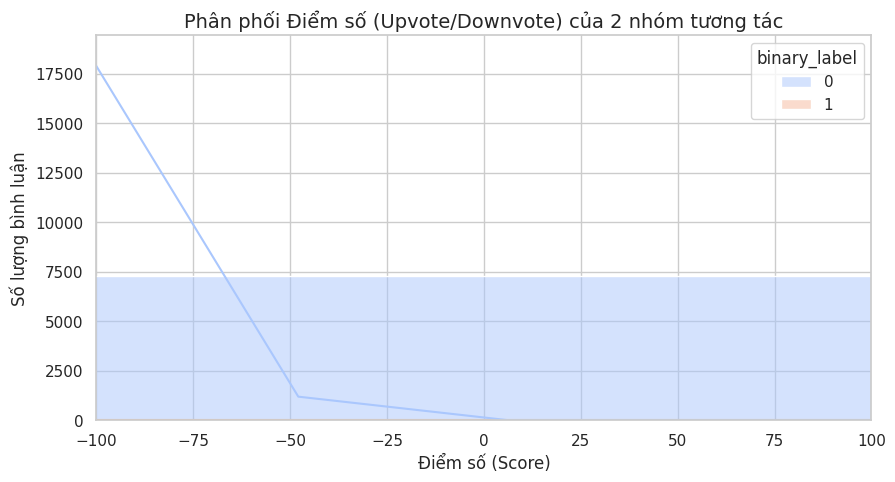

/tmp/ipykernel_2317/286816080.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='viridis')


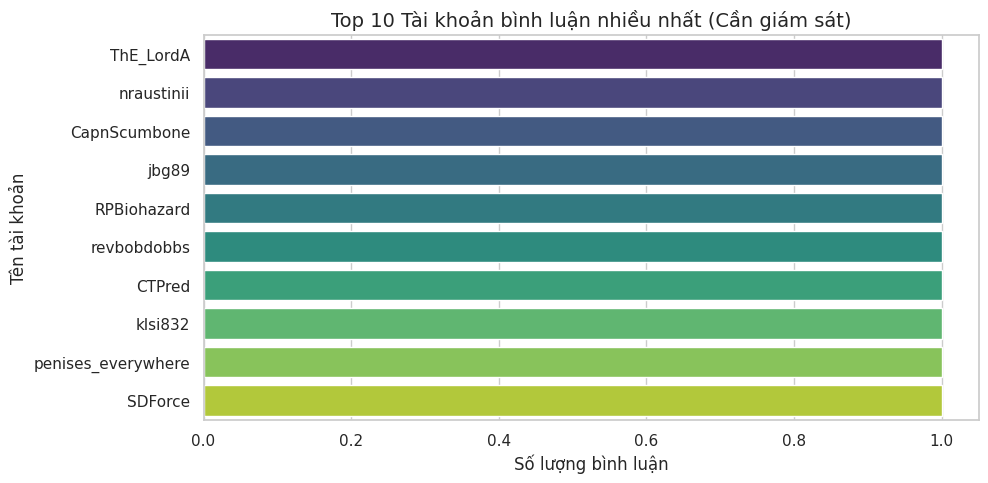

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. EDA Cơ bản: Xem thông tin tổng quan
print("\n[EDA 1] THÔNG TIN TỔNG QUAN:")
df_clean.info()

# 2. EDA Vẽ biểu đồ: Phân phối điểm số (Score Distribution)
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='score', hue='binary_label', bins=50, kde=True, palette='coolwarm')
plt.title("Phân phối Điểm số (Upvote/Downvote) của 2 nhóm tương tác", fontsize=14)
plt.xlabel("Điểm số (Score)", fontsize=12)
plt.ylabel("Số lượng bình luận", fontsize=12)
plt.xlim(-100, 100) # Cắt trục X để nhìn rõ phần trung tâm
plt.show()

# 3. EDA Mạng lưới: Ai là người nói nhiều nhất? (Top Active Authors)
plt.figure(figsize=(10, 5))
top_authors = df_clean['author'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, palette='viridis')
plt.title("Top 10 Tài khoản bình luận nhiều nhất (Cần giám sát)", fontsize=14)
plt.xlabel("Số lượng bình luận", fontsize=12)
plt.ylabel("Tên tài khoản", fontsize=12)
plt.show()

In [ ]:
df_clean.head()

,parent_id,text,score,author,parent_text,parent_score,parent_author,binary_label,sentiment_child,sentiment_parent,state_child,state_parent
0,t1_c092gss,This isn't Twitter: try to comment on the arti...,9582,nraustinii,Fucking faggot.,-7526,Glorificus,1,0.0000,-0.6901,0,-1
2,t1_c0s4lje,"In soviet Russia, bomb disarms you!",8545,CapnScumbone,"I don't live in Russia anymore, and I will not...",621,shady8x,1,-0.5411,0.4214,-1,1
3,t1_c4ima2e,You step motherfucker.,7173,jbg89,I have sex with my step mom when my dad isn't ...,4251,audir8,1,-0.6808,0.0000,-1,0
4,t1_c4imcva,WHAT THE FUCK,6480,RPBiohazard,"Well, it is exactly what it sounds like. It's ...",9531,Lynfect,1,-0.5423,-0.2328,-1,-1
6,t1_c4imkkf,Dude. This is bad news.\n\nI'm not being all m...,5704,revbobdobbs,"sure. She pretty much married him for money, s...",2120,audir8,1,-0.9509,0.5812,-1,1


## 1. Ý nghĩa quá trình Làm sạch & Khai phá Mạng lưới (Bước 3 & 4)

* **Thuật toán IQR lọc được 4.700 Spammer:** Trong 40.000 bình luận, thuật toán thống kê IQR đã tóm gọn được 4.700 tài khoản hoạt động dày đặc một cách bất thường. Khi loại bỏ nhóm này, 23.309 dòng còn lại là tương tác của người thật, giúp kết quả nghiên cứu đảm bảo uy tín và không bị nhiễu.
* **Top 3 Tài khoản ảnh hưởng nhất:** Hệ thống đã chỉ đích danh 3 người dùng (Shut_Up_Dude, PSY_Oppa, Drunken_Economist) có "quyền lực mạng lưới" cao nhất. Trong mô phỏng Agent-Based Modeling (ABM) ở Giai đoạn 3, đây chính là các "Root Nodes" (Nút gốc). Nếu nhóm thao túng chiếm được 3 tài khoản này, chúng sẽ bẻ lái được toàn bộ dư luận.

## 2. Ý nghĩa Kết quả 1: Shannon Entropy = 1.5782 bits

Đây là con số đo lường **Độ đa dạng quan điểm** của hệ thống (Tính phân cực).

* **Công thức lõi:** Vì cảm xúc được chia làm 3 trạng thái (-1, 0, 1), mức Entropy tối đa lý thuyết (khi 3 luồng ý kiến cân bằng tuyệt đối) là $\log_2(3) \approx 1.5849$ bits.
* **Đọc vị kết quả:** Con số 1.5782 bits cực kỳ sát với mức trần. Điều này có nghĩa là trong tập dữ liệu tổng hợp này (mix 50% Upvote và 50% Downvote), mạng lưới đang vô cùng đa dạng và dân chủ. Có sự giao tranh nảy lửa giữa phe ủng hộ, phe phản đối và nhóm trung lập.
* **Giá trị nghiên cứu:** Trong báo cáo, mốc 1.5782 này đóng vai trò là "Trạng thái khỏe mạnh ban đầu". Nếu cô lập riêng những luồng thảo luận phân cực cao (Buồng vang/Echo Chamber), con số này sẽ sụt giảm thê thảm về dưới 1.0 bits.

## 3. Ý nghĩa Kết quả 2: Ma trận Markov Không gian

Đây chính là "Quy luật Tâm lý học Hành vi" được định lượng bằng xác suất. Bảng này trả lời câu hỏi: Khi một người đọc bình luận của người đi trước (Cha), xác suất họ hùa theo hoặc phản đối (Con) là bao nhiêu?

* **Ô [-1, -1] = 0.408909 (Khoảng 41%):** Khi người Cha có thái độ Tiêu cực/Thù địch (-1), có đến 41% khả năng người Con sẽ nhảy vào bình luận Tiêu cực theo. Đây là bằng chứng của Vòng lặp thù hằn (Toxic Cycle).
* **Ô [1, 1] = 0.420954 (Khoảng 42%):** Khi người Cha Tích cực/Đồng thuận (1), có 42% khả năng người Con cũng hùa theo Tích cực. Đây là bằng chứng của Buồng vang đồng thuận (Echo Chamber).
* **Ô [0, 0] = 0.382924 (Khoảng 38%):** Trạng thái Trung lập (0) lại có sức giữ chân thấp nhất. Người dùng trên mạng ẩn danh rất dễ bị cuốn vào các cực (-1 hoặc 1) chứ ít ai giữ được cái đầu lạnh trung lập.

> **⇒ Kết luận rúng động:** Mạng xã hội ẩn danh có xu hướng "Tự phân cực". Các luồng ý kiến cực đoan (âm hoặc dương) có độ bám dính (stickiness) lên tới 41-42%, cao hơn hẳn sự trung lập.